In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter
import os

### **Treatment-induced system dynamics**

In [2]:
# system parameters for training
def randomize_parameters(seed=None):
    if seed is not None:
        np.random.seed(seed)
        
    base = {
        'alpha1': 0.01701, 'alpha2': 0.02828, 'beta1': 0.01091, 'x1_0': 13.24535, 
        'x2_0': 0.11643, 'c2': 0.98015, 'k1': 0.48839, 'k2': 2.18834, 'k3': 7.14527,
        'beta2': 0.01821, 'a0': 25.83193, 'gamma': 0.08868, 'k4': 0.47674, 'm1': 0.00005, 'c1': 0.98015}
    
    base = {
    'alpha1': 0.0247, 'alpha2': 0.02595, 'beta1': 0.00805, 'x1_0': 15, 
    'x2_0': 0.1, 'c2': 1, 'k1': 0, 'k2': 2, 'k3': 8,
    'beta2': 0.0195, 'a0': 30, 'gamma': 0.08, 'k4': 0.5, 'm1': 0.00005, 'c1': 1}
    
    params = {}
        
    for key, val in base.items():
        low = 0.25 * val
        high = 1.75 * val
        params[key] = np.random.uniform(low, high)
        
    return params

In [3]:
def On_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''

    alpha1 = params['alpha1']; alpha2 = params['alpha2']
    beta1 = params['beta1']; beta2 = params['beta2']
    x1_0 = params['x1_0']; x2_0 = params['x2_0']
    a0 = params['a0']; gamma = params['gamma']; m1 = params['m1']
    c1 = params['c1']; c2 = params['c2']
    k1 = params['k1']; k2 = params['k2']; k3 = params['k3']; k4 = params['k4']
    
    # iteration paramters
    h = 2                      # step length
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7   # (e.g. week 0 -> i will loop for 7 days)
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*1)*h+A[t] # u(t)=1, on-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

In [4]:
def Off_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''    
    
    alpha1 = params['alpha1']; alpha2 = params['alpha2']
    beta1 = params['beta1']; beta2 = params['beta2']
    x1_0 = params['x1_0']; x2_0 = params['x2_0']
    a0 = params['a0']; gamma = params['gamma']; m1 = params['m1']
    c1 = params['c1']; c2 = params['c2']
    k1 = params['k1']; k2 = params['k2']; k3 = params['k3']; k4 = params['k4']
    
    # iteration paramters 
    h = 2
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*0)*h+A[t] # u(t)=0, off-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

### **Q-Learning**

In [5]:
# q_table_file = r'C:\Users\amp87\Desktop\QLearning\QLearning\q_table.csv'

N_STATES = 4*12*5*4    # 4 weeks/month * 12 months/year * 5 years * 4 ordinal data (high, medium, proper, low)
EPSILON = 1.0          # init value, < EPSILON then greedy
EPSILON_decay = 0.999  # decay factor, < EPSILON then greedy (allows the random exploring)
ALPHA = 0.05           # learning rate
GAMMA = 0.9            # discount factor

MAX_EPISODES = 15000   # maximum training episodes
Y_UPPER = 10           # serum PSA concentration y(t)'s upper bound, threshold for biomedical recurrence (unit: ng/10mL)
# Y_LOWER = 1          # y(t) lower bound
# INIT = [30, 15, 0.01]  # initial conditions
# a0 = 30                # a0

ACTIONS = ['med', 'non_med']  # possible actions, medication (on), non-medication (off)

In [6]:
def decode_state(state_index):
    ordinal = state_index % 4           # Ordinal (0: low, 1: proper, 2: medium, 3: high)
    week = (state_index//4) % 4         # Week    (0 to 3 within a month)
    month = (state_index//(4*4)) % 12   # Month   (0 to 11 within a year)
    year = state_index // (4*4*12)      # Year    (0 to 4 within 5 years)
    return year, month, week, ordinal
    
def is_terminal_state(state_index):
    year, month, week, _ = decode_state(state_index)
    return year == 4 and month == 11 and week == 3

##### **Q-Table**

In [7]:
# initialie the Q-table (or use an existing one)
def build_q_table(n_States, Actions):
    Table = pd.DataFrame(np.zeros((n_States, len(Actions))), columns = Actions)
    return Table

##### **Action**

In [8]:
def choose_action(State, Q_table, EPSILON_n_iter):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state

    # non-greedy, or the state hasn't been explored yet -> act randomly
    if (np.random.uniform() < EPSILON*(EPSILON_decay**EPSILON_n_iter)) or (State_Actions.all() == 0):  
        Action_SELECTED = np.random.choice(ACTIONS)
    else:
        if np.random.uniform() < 0.999:
            Action_SELECTED = State_Actions.idxmax()  # acts greedy
        else:
            Action_SELECTED = np.random.choice(ACTIONS)
    
    return Action_SELECTED, EPSILON_n_iter

In [9]:
def choose_best_action(State, Q_table):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state
    Action_SELECTED = State_Actions.idxmax()  # acts greedy
    return Action_SELECTED

##### **State**

In [10]:
# helper function to categorize serum PSA levels (y_t) into ordinal categories
def y_to_scope(y_t):
    '''
    returns the scope: Ordinal category (0: low, 1: proper, 2: medium, 3: high)
    '''
    if 0 <= y_t < 10:
        scope = 0  # Low
    elif 10 <= y_t < 20:
        scope = 1  # Proper
    elif 20 <= y_t < 30:
        scope = 2  # Medium
    elif 30 <= y_t:
        scope = 3  # High

    return scope

In [11]:
# helper function to check whether the list has any element >= the upper threhold
def check_biochemical_progression(in_PSA_list, in_deriv_PSA):
    """
    progression: serum PSA level > 10 ng/mL and dY > 0.1 for 3 consecutive weeks (21 days)
    """
    # <21 days
    if len(in_PSA_list) < 21:
        return False
        
    else:  
        biom_rec = True
        for day in range(len(in_PSA_list)-22, len(in_PSA_list)-1):
            if in_PSA_list[day] <= Y_UPPER or in_deriv_PSA[day] <= 0.1:
                biom_rec = False
        return biom_rec

In [12]:
# determine the new state (New_State) and immediate reward (Reward) of an agent after taking an action
def get_env_feedback(Current_State, Action, Week, A, X1, X2, Y, dY, params):
    '''
    do switching, check med-/no med-induced dynamics 
    Current_State: current dyn.
    Action: 'med' or 'non_med'
    Week: current week
    A, X1, X2, Y, dY: lists containing the past cond.s
    '''
    a0 = params['a0']
    
    if Action == 'med':
        A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = -3  # med
    else:
        A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = 0   # no med

    Current_y = Y[-1]                  # the current serum PSA level at the end of the week
    PSA_scope = y_to_scope(Current_y)  # action induced PSA level (0: low, 1: proper, 2: medium, 3: high)
    
    # biochemical reccurrence?
    is_rec = check_biochemical_progression(Y, dY)
    
    # check terminal condition: environment ends when the state corresponds to the last time step (end of 5 years, i.e., week 240)
    is_finished = (Week >= (N_STATES // 4) - 1)

    if is_rec:
        New_State = -1
        Reward = -5000
    elif is_finished:
        New_State = -1
        Reward = 1000   # successful long-living rewards: recurrence-free survival(RFS), reaches the terminal
    else:
        # N_STATES: [Year][Month][Week][Ordinal] -> 4 * 12 * 5 * 4
        next_week_base = (Week + 1) * 4
        New_State = next_week_base + PSA_scope
        
        Reward = -2.0 * Current_y 
        if Action == 'med':
            Reward -= 2

    return New_State, Reward, A, X1, X2, Y, dY

### **The Main QL Algorithm**

In [13]:
Training_Mode = True

In [14]:
def RL_training_process(params):
    # build (initialize) the Q table
    Q_table = build_q_table(N_STATES, ACTIONS) 

    # save the best Q table
    best_Q_score = -np.inf
    best_Q = None

    EPSILON_n_iter = 0

    alpha1 = params['alpha1']; alpha2 = params['alpha2']
    beta1 = params['beta1']; beta2 = params['beta2']
    x1_0 = params['x1_0']; x2_0 = params['x2_0']
    a0 = params['a0']; gamma = params['gamma']; m1 = params['m1']
    c1 = params['c1']; c2 = params['c2']
    k1 = params['k1']; k2 = params['k2']; k3 = params['k3']; k4 = params['k4']

    best_Q_tables = []
    highest_PFS_week = -np.inf
    least_usage = None
    
    for episode in range(MAX_EPISODES):
        # init env
        Week = 0
        EPSILON_n_iter = EPSILON_n_iter + 1 # starts the decay for every training iteration
        terminate = False
        
        # init lists
        a_init = params['a0']; x1_init = params['x1_0']; x2_init = params['x2_0']
        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_List_QL = []
        med_punishment = 0
        
        Current_State = y_to_scope(Y[0]) # init states (0-3)

        while not terminate:
            Current_Action, EPSILON_n_iter = choose_action(Current_State, Q_table, EPSILON_n_iter)
            Action_List_QL.extend([Current_Action]*7)
            
            if Current_Action == 'med':
                med_punishment = med_punishment + 1
            # interact with the env
            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(Current_State, Current_Action, Week, A, X1, X2, Y, dY, params)
            
            # update Q-table
            Q_val_predict = Q_table.loc[Current_State, Current_Action] 
            
            if New_State != -1:
                Q_val_target = Reward + GAMMA * Q_table.iloc[New_State, :].max()
            else:
                Q_val_target = Reward
                terminate = True
                if Week >= highest_PFS_week:
                    highest_PFS_week = Week
                    if least_usage == None or med_punishment <= least_usage:
                        least_usage = med_punishment
                # if episode%1000 == 0: # if Week > 150: # great Episodes
                    # print(f'Episode: {episode} | Weeks Survived: {Week+1} | Final PSA: {Y[-1]:.2f}')
                if Week >= 238:
                    best_Q_tables.append({"weeks": Week, "psa": Y, "Q_tab": Q_table,
                                          "act_list": Action_List_QL,
                                          "med_puni": med_punishment})

            Q_table.loc[Current_State, Current_Action] += ALPHA * (Q_val_target - Q_val_predict)
            
            # state shift
            Current_State = New_State
            Week += 1
            
            # cool
            if Week >= (N_STATES // 4):
                terminate = True

    if len(best_Q_tables)>=1:
        df = pd.DataFrame(best_Q_tables)

        lowest_med_punishment = np.inf
        best_of_the_bests = None

        for idx, row in df.iterrows():
            if row['med_puni'] < lowest_med_punishment: # choose the one with the best medication strategy
                best_of_the_bests = row

        best_Q_table = best_of_the_bests["Q_tab"]
        best_PSA_ctrl = best_of_the_bests["psa"]
        best_Act_list = best_of_the_bests["act_list"]
        best_PFS_reached = best_of_the_bests["weeks"]
        best_med_usage = best_of_the_bests["med_puni"]
        # best_Q_table.to_csv(Q_table_file, index=False)
        return best_Q_table, best_PSA_ctrl, best_Act_list, best_PFS_reached+1, best_med_usage

    else:
        Q_table = pd.read_csv('/Users/ekeulseuji/Downloads/Q_table_for_use.csv')
        return Q_table, [], [], highest_PFS_week, least_usage

## **Patient Simulation**

In [15]:
Med_Usage_RL = []
Med_Usage_ONF = []

In [16]:
def simulate_patient(params, strategy, Q_table, max_weeks=240):
    """
    params : a dict including all system params
    strategy : 'RL'/'ONF'
    Q_table : DataFrame (strategy='RL') or None (strategy='ONF') 
    max_weeks : progression-free weeks
    returns (time_weeks, event)  event=1 (progression), 0 (censored, progression-free survival)
    """
    alpha1 = params['alpha1']; alpha2 = params['alpha2']
    beta1 = params['beta1']; beta2 = params['beta2']
    x1_0 = params['x1_0']; x2_0 = params['x2_0']
    a0 = params['a0']; gamma = params['gamma']; m1 = params['m1']
    c1 = params['c1']; c2 = params['c2']
    k1 = params['k1']; k2 = params['k2']; k3 = params['k3']; k4 = params['k4']

    A = [a0]
    X1 = [x1_0]
    X2 = [x2_0]
    Y = [c1 * X1[0] + c2 * X2[0]]
    dY = []
    med_usage_count = 0
    current_action = 'med'

    week = 0

    if strategy == 'RL':
        # the training process (half/full), or just use the Q-table
        if Q_table == None:
            Q_table, PSA_List, Action_list_QL, week, med_usage_count = RL_training_process(params)
            # draw_graphs(PSA_List, Action_list_QL)
            if week < max_weeks:
                Med_Usage_RL.append({'Week': week, 'MedUsage': med_usage_count})
                return (week, 1)
            else:
                Med_Usage_RL.append({'Week': week, 'MedUsage': med_usage_count})
                return (week, 0)
            
        else:
            while week < max_weeks:
                state = y_to_scope(Y[-1])
                current_action = choose_best_action(state, Q_table)     

                if current_action == 'med':
                    A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, week, params)
                    med_usage_count += 1
                elif current_action == 'non_med':
                    A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, week, params)

                if check_biochemical_progression(Y, dY) == True:
                    break;
                week += 1

            if check_biochemical_progression(Y, dY) == True:
                Med_Usage_RL.append({'Week': week, 'MedUsage': med_usage_count})
                return (week, 1)
            else:
                Med_Usage_RL.append({'Week': week, 'MedUsage': med_usage_count})         
                return (week, 0)

    elif strategy == 'ONF':
        while week < max_weeks:            
            if week > 0: # do switching
                if Y[-1] > 10.0 and dY[-1] > 0.1:
                    current_action = 'med'
                elif Y[-1] <= 3.0 and dY[-1] < 0.1:
                    current_action = 'non_med'
                else:
                    current_action = current_action

            if current_action == 'med':
                A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, week, params)
                med_usage_count += 1
            elif current_action == 'non_med':
                A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, week, params)

            if check_biochemical_progression(Y, dY) == True:
                break;
            week += 1

        if check_biochemical_progression(Y, dY) == True:
            Med_Usage_ONF.append({'Week': week, 'MedUsage': med_usage_count})
            return (week, 1)
        else:
            Med_Usage_ONF.append({'Week': week, 'MedUsage': med_usage_count})         
            return (week, 0)

### **Final Performances**

In [17]:
def draw_graphs(PSA_List, Action_list_QL):
    fixed_length = 1680

    if len(PSA_List) < fixed_length:
        PSA_List_padded = PSA_List + [0] * (fixed_length - len(PSA_List))
    else:
        PSA_List_padded = PSA_List[:fixed_length]
    
    Y_index = [i for i in range(len(PSA_List_padded))]
    Y_index2 = [i for i in range(len(PSA_List))]
    
    plt.figure(figsize=(40,5))
    plt.plot(Y_index, PSA_List_padded, color='black', alpha=0.0, linewidth=1.5, linestyle='-')
    
    plt.plot(Y_index2, PSA_List, color='black', linewidth=1.5, linestyle='-', label='Serum PSA')
    
    # plt.plot(Y_index2[-21:], PSA_List[-21:], color='crimson', linewidth=1.5, linestyle='--', label='Signifies Progression')
    
    A_index = 0
    shadow_segments = []
    
    if len(Action_list_QL) < fixed_length:
        Action_list_QL_padded = Action_list_QL + ['0'] * (fixed_length - len(Action_list_QL))
    else:
        Action_list_QL_padded = Action_list_QL[:fixed_length]
    
    Y_index = [i for i in range(len(Action_list_QL_padded))]
    
    for act in Action_list_QL_padded:
        if act == 'med':
            plt.plot([A_index, A_index+1], [23,23], color='m', linewidth=1.5)
            shadow_segments.append((A_index, A_index+1))
        elif act == 'non_med':
            plt.plot([A_index, A_index+1], [0,0], color='black', linewidth=1.5)
        elif act == '0':
            plt.plot([A_index, A_index+1], [0,0], color='black', linewidth=1.5)
        A_index = A_index + 1
    
    labelled = False
    for start, end in shadow_segments:
        if labelled == False:
            plt.fill_between([start, end], 0, 23, color='m', alpha=0.05, label='On Treatment')
            labelled = True
        else:
            plt.fill_between([start, end], 0, 23, color='m', alpha=0.05)
    
    plt.grid(True)
    plt.xlabel('Time', fontsize=18)
    plt.ylabel('Serum PSA (ng/mL)', fontsize=18)
    plt.title('Serum PSA Level Over Time with Actions Indicated (Q-Learning)\n', fontsize=18)
    plt.legend(fontsize=18, loc='upper right')
    # plt.savefig('/Users/ekeulseuji/Downloads/QL_OUT.pdf', bbox_inches='tight')
    plt.show()

    # print('len(shadow_segments): ', len(shadow_segments))

### **Main Survival Analysis**

In [18]:
def run_simulation(n_patients, seed):
    np.random.seed(seed)
    results_RL = []
    results_ONF = []
    for i in range(n_patients):
        params = randomize_parameters(seed=i)
        Q_table = None
        group_assignment = np.random.choice(['RL','ONF'], p=[0.5, 0.5])
        
        if i%10 == 0:
            print('The', i, "th virtual patient's treatment plan:", group_assignment)

        if group_assignment == 'RL':
            # Q_table = pd.read_csv('/Users/ekeulseuji/Downloads/Q_table_Case3.csv')
            time_rl, event_rl = simulate_patient(params, 'RL', None) # Q_table
            results_RL.append({'patient': i, 'time_RL': time_rl, 'event_RL': event_rl})

        elif group_assignment == 'ONF':
            time_onoff, event_onoff = simulate_patient(params, 'ONF', None)
            results_ONF.append({'patient': i, 'time_ONF': time_onoff, 'event_ONF': event_onoff})
        
    df_results_RL = pd.DataFrame(results_RL)
    df_results_ONF = pd.DataFrame(results_ONF)
    
    # draw_graphs(PSA_List, Action_list_QL)
    
    return df_results_RL, df_results_ONF

In [19]:
df_RL, df_ONF = run_simulation(n_patients=500, seed=1983331)

The 0 th virtual patient's treatment plan: RL
The 10 th virtual patient's treatment plan: ONF
The 20 th virtual patient's treatment plan: RL
The 30 th virtual patient's treatment plan: RL
The 40 th virtual patient's treatment plan: ONF
The 50 th virtual patient's treatment plan: ONF
The 60 th virtual patient's treatment plan: ONF
The 70 th virtual patient's treatment plan: ONF
The 80 th virtual patient's treatment plan: RL
The 90 th virtual patient's treatment plan: ONF
The 100 th virtual patient's treatment plan: ONF
The 110 th virtual patient's treatment plan: RL
The 120 th virtual patient's treatment plan: ONF
The 130 th virtual patient's treatment plan: RL
The 140 th virtual patient's treatment plan: ONF
The 150 th virtual patient's treatment plan: RL
The 160 th virtual patient's treatment plan: ONF
The 170 th virtual patient's treatment plan: ONF
The 180 th virtual patient's treatment plan: RL
The 190 th virtual patient's treatment plan: RL
The 200 th virtual patient's treatment p

### **Analysis**

In [20]:
def survival_anal(df_results_RL, df_results_ONF):
    T_RL = df_results_RL['time_RL']
    E_RL = df_results_RL['event_RL']
    T_ONF = df_results_ONF['time_ONF']
    E_ONF = df_results_ONF['event_ONF']

    # fitting the Kaplan-Meier model
    kmf_RL = KaplanMeierFitter()
    kmf_ONF = KaplanMeierFitter()
    
    kmf_RL.fit(T_RL, E_RL, label='RL Strategy')
    kmf_ONF.fit(T_ONF, E_ONF, label='Simple On-Off Strategy')

    ci_RL = kmf_RL.confidence_interval_survival_function_
    ci_ONF = kmf_ONF.confidence_interval_survival_function_

    # print(ci_RL)
    # print(ci_ONF)
    
    # 95% CI
    # median_RL = kmf_RL.median_survival_time_
    # median_ONF = kmf_ONF.median_survival_time_

    lower_col_RL = 'RL Strategy_lower_0.95'
    upper_col_RL = 'RL Strategy_upper_0.95'
    lower_col_ONF = 'Simple On-Off Strategy_lower_0.95'
    upper_col_ONF = 'Simple On-Off Strategy_upper_0.95'
    
    def get_median_with_ci(kmf, ci_df, lower_col, upper_col):
        median = kmf.median_survival_time_
        
        if np.isfinite(median):
            idx = (kmf.survival_function_.index - median).abs().argmin()
            lower_ci = ci_df.iloc[idx][lower_col]
            upper_ci = ci_df.iloc[idx][upper_col]
        else:
            # the median survival time exceeds the observation period, use the last time point's CI
            lower_ci = ci_df.iloc[-1][lower_col]
            upper_ci = ci_df.iloc[-1][upper_col]
        
        return median, lower_ci, upper_ci
    
    median_RL, lower_RL, upper_RL = get_median_with_ci(kmf_RL, ci_RL, lower_col_RL, upper_col_RL)
    median_ONF, lower_ONF, upper_ONF = get_median_with_ci(kmf_ONF, ci_ONF, lower_col_ONF, upper_col_ONF)
    
    # Log-rank Test
    logrank_result = logrank_test(T_RL, T_ONF, 
                                   event_observed_A=E_RL, 
                                   event_observed_B=E_ONF)
    
    chi2 = logrank_result.test_statistic
    p_value = logrank_result.p_value
    
    # Hazard Ratio
    df_merged = pd.DataFrame({
        'time': list(T_RL) + list(T_ONF),
        'event': list(E_RL) + list(E_ONF),
        'group': ['RL'] * len(T_RL) + ['ONF'] * len(T_ONF)})
    
    cph = CoxPHFitter()
    cph.fit(df_merged, duration_col='time', event_col='event', formula='group')
    hr = np.exp(cph.params_['group_T[RL]'])  # Hazard Ratio (RL vs ONF)
    hr_ci_lower = np.exp(cph.confidence_intervals_.loc['group_T[RL]', '95% lower-bound'])
    hr_ci_upper = np.exp(cph.confidence_intervals_.loc['group_T[RL]', '95% upper-bound'])
    
    print("=" * 60)
    print("SURVIVAL ANALYSIS RESULTS")
    print("=" * 60)
    print(f"\nMedian Progression-Free Survival:")
    print(f"  RL Strategy:     {median_RL:.1f} weeks (95% CI: {lower_RL:.1f}–{upper_RL:.1f})")
    print(f"  Simple On-Off:   {median_ONF:.1f} weeks (95% CI: {lower_ONF:.1f}–{upper_ONF:.1f})")
    
    print(f"\nLog-rank Test:")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  p-value: {p_value:.4f}")
    
    print(f"\nCox Proportional Hazards Model:")
    print(f"  Hazard Ratio (RL vs ONF): {hr:.3f} (95% CI: {hr_ci_lower:.3f}–{hr_ci_upper:.3f})")
    
    plt.figure(figsize=(8, 6))
    ax = kmf_RL.plot_survival_function(label='RL Strategy')
    kmf_ONF.plot_survival_function(ax=ax, label='Simple On-Off Strategy')
    
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Median reference (50%)')
    plt.axvline(x=median_RL, color='blue', linestyle=':', alpha=0.7, label=f'RL Median: {median_RL:.0f} wks')
    plt.axvline(x=median_ONF, color='orange', linestyle=':', alpha=0.7, label=f'ONF Median: {median_ONF:.0f} wks')
    
    plt.title('Kaplan‑Meier Survival Curves', fontsize=14)
    plt.xlabel('Time (weeks)', fontsize=12)
    plt.ylabel('Progression‑Free Survival Probability', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(loc='lower left')
    
    plt.tight_layout()
    plt.show()
    
    stats = {
        'median_RL': median_RL,
        'median_RL_CI': (lower_RL, upper_RL),
        'median_ONF': median_ONF,
        'median_ONF_CI': (lower_ONF, upper_ONF),
        'chi2': chi2,
        'p_value': p_value,
        'hazard_ratio': hr,
        'hr_CI': (hr_ci_lower, hr_ci_upper)}
    
    return stats

In [21]:
def survival_anal(df_results_RL, df_results_ONF):
    T_RL = df_results_RL['time_RL']
    E_RL = df_results_RL['event_RL']
    T_ONF = df_results_ONF['time_ONF']
    E_ONF = df_results_ONF['event_ONF']

    kmf_RL = KaplanMeierFitter()
    kmf_ONF = KaplanMeierFitter()
    
    kmf_RL.fit(T_RL, E_RL, label='RL Strategy')
    kmf_ONF.fit(T_ONF, E_ONF, label='Simple On-Off Strategy')
    
    ci_RL = kmf_RL.confidence_interval_survival_function_
    ci_ONF = kmf_ONF.confidence_interval_survival_function_
    
    # 列名
    lower_col_RL = 'RL Strategy_lower_0.95'
    upper_col_RL = 'RL Strategy_upper_0.95'
    lower_col_ONF = 'Simple On-Off Strategy_lower_0.95'
    upper_col_ONF = 'Simple On-Off Strategy_upper_0.95'
    
    def get_median_with_ci(kmf, ci_df, lower_col, upper_col):
        median = kmf.median_survival_time_
        
        if np.isfinite(median):
            idx = (kmf.survival_function_.index - median).abs().argmin()
            lower_ci = ci_df.iloc[idx][lower_col]
            upper_ci = ci_df.iloc[idx][upper_col]
        else:
            lower_ci = ci_df.iloc[-1][lower_col]
            upper_ci = ci_df.iloc[-1][upper_col]
        
        return median, lower_ci, upper_ci
    
    median_RL, lower_RL, upper_RL = get_median_with_ci(kmf_RL, ci_RL, lower_col_RL, upper_col_RL)
    median_ONF, lower_ONF, upper_ONF = get_median_with_ci(kmf_ONF, ci_ONF, lower_col_ONF, upper_col_ONF)
    
    # Log-rank test
    logrank_result = logrank_test(T_RL, T_ONF, 
                                   event_observed_A=E_RL, 
                                   event_observed_B=E_ONF)
    
    chi2 = logrank_result.test_statistic
    p_value = logrank_result.p_value
    
    events_RL = E_RL.sum()
    events_ONF = E_ONF.sum()
    n_RL = len(E_RL)
    n_ONF = len(E_ONF)
    
    print("=" * 60)
    print("SURVIVAL ANALYSIS RESULTS")
    print("=" * 60)
    print(f"\nSample size:")
    print(f"  RL Strategy:     {n_RL} patients, {events_RL} events (progression)")
    print(f"  Simple On-Off:   {n_ONF} patients, {events_ONF} events (progression)")
    print(f"\nMedian Progression-Free Survival:")
    print(f"  RL Strategy:     {median_RL:.1f} weeks (95% CI: {lower_RL:.1f}–{upper_RL:.1f})")
    print(f"  Simple On-Off:   {median_ONF:.1f} weeks (95% CI: {lower_ONF:.1f}–{upper_ONF:.1f})")
    print(f"\nLog-rank test: chi2 = {chi2:.2f}, p = {p_value:.4f}")
    

    sf_RL = kmf_RL.survival_function_
    sf_ONF = kmf_ONF.survival_function_
    
    if 240 in sf_RL.index:
        pfs_240_RL = sf_RL.loc[240].values[0]
    else:
        idx_RL = (sf_RL.index - 240).abs().argmin()
        pfs_240_RL = sf_RL.iloc[idx_RL].values[0]
    
    if 240 in sf_ONF.index:
        pfs_240_ONF = sf_ONF.loc[240].values[0]
    else:
        idx_ONF = (sf_ONF.index - 240).abs().argmin()
        pfs_240_ONF = sf_ONF.iloc[idx_ONF].values[0]
    
    print(f"\n240-week PFS rate:")
    print(f"  RL Strategy:     {pfs_240_RL*100:.1f}%")
    print(f"  Simple On-Off:   {pfs_240_ONF*100:.1f}%")
    
    plt.figure(figsize=(8, 6))
    ax = kmf_RL.plot_survival_function(label='RL Strategy')
    kmf_ONF.plot_survival_function(ax=ax, label='Simple On-Off Strategy')
    
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Median reference (50%)')
    
    if np.isfinite(median_RL) and median_RL <= 240:
        plt.axvline(x=median_RL, color='blue', linestyle=':', alpha=0.7, 
                   label=f'RL Median: {median_RL:.0f} wks')
    if np.isfinite(median_ONF):
        plt.axvline(x=median_ONF, color='orange', linestyle=':', alpha=0.7, 
                   label=f'ONF Median: {median_ONF:.0f} wks')
    
    plt.title('Kaplan‑Meier Survival Curves', fontsize=14)
    plt.xlabel('Time (weeks)', fontsize=12)
    plt.ylabel('Progression‑Free Survival Probability', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.show()
    
    return {
        'median_RL': median_RL,
        'median_RL_CI': (lower_RL, upper_RL),
        'median_ONF': median_ONF,
        'median_ONF_CI': (lower_ONF, upper_ONF),
        'pfs_240_RL': pfs_240_RL,
        'pfs_240_ONF': pfs_240_ONF,
        'chi2': chi2,
        'p_value': p_value,
        'n_RL': n_RL,
        'n_ONF': n_ONF,
        'events_RL': events_RL,
        'events_ONF': events_ONF}

In [22]:
def survival_anal(df_results_RL, df_results_ONF):
    T_RL = df_results_RL['time_RL']
    E_RL = df_results_RL['event_RL']
    T_ONF = df_results_ONF['time_ONF']
    E_ONF = df_results_ONF['event_ONF']

    kmf_RL = KaplanMeierFitter()
    kmf_ONF = KaplanMeierFitter()
    
    kmf_RL.fit(T_RL, E_RL, label='RL Strategy')
    kmf_ONF.fit(T_ONF, E_ONF, label='Simple On-Off Strategy')
    
    ci_RL = kmf_RL.confidence_interval_survival_function_
    ci_ONF = kmf_ONF.confidence_interval_survival_function_
    
    lower_col_RL = 'RL Strategy_lower_0.95'
    upper_col_RL = 'RL Strategy_upper_0.95'
    lower_col_ONF = 'Simple On-Off Strategy_lower_0.95'
    upper_col_ONF = 'Simple On-Off Strategy_upper_0.95'
    
    def get_median_with_ci(kmf, ci_df, lower_col, upper_col):
        median = kmf.median_survival_time_
        
        if np.isfinite(median):
            idx = abs(kmf.survival_function_.index - median).argmin()
            lower_ci = ci_df.iloc[idx][lower_col]
            upper_ci = ci_df.iloc[idx][upper_col]
        else:
            lower_ci = ci_df.iloc[-1][lower_col]
            upper_ci = ci_df.iloc[-1][upper_col]
        
        return median, lower_ci, upper_ci
    
    median_RL, lower_RL, upper_RL = get_median_with_ci(kmf_RL, ci_RL, lower_col_RL, upper_col_RL)
    median_ONF, lower_ONF, upper_ONF = get_median_with_ci(kmf_ONF, ci_ONF, lower_col_ONF, upper_col_ONF)
    
    # Log-rank test
    logrank_result = logrank_test(T_RL, T_ONF, 
                                   event_observed_A=E_RL, 
                                   event_observed_B=E_ONF)
    
    chi2 = logrank_result.test_statistic
    p_value = logrank_result.p_value
    
    events_RL = E_RL.sum()
    events_ONF = E_ONF.sum()
    n_RL = len(E_RL)
    n_ONF = len(E_ONF)
    
    print("=" * 60)
    print("SURVIVAL ANALYSIS RESULTS")
    print("=" * 60)
    print(f"\nSample size:")
    print(f"  RL Strategy:     {n_RL} patients, {events_RL} events (progression)")
    print(f"  Simple On-Off:   {n_ONF} patients, {events_ONF} events (progression)")
    print(f"\nMedian Progression-Free Survival:")
    print(f"  RL Strategy:     {median_RL:.1f} weeks (95% CI: {lower_RL:.1f}–{upper_RL:.1f})")
    print(f"  Simple On-Off:   {median_ONF:.1f} weeks (95% CI: {lower_ONF:.1f}–{upper_ONF:.1f})")
    print(f"\nLog-rank test: chi2 = {chi2:.2f}, p = {p_value:.4f}")
    

    sf_RL = kmf_RL.survival_function_
    sf_ONF = kmf_ONF.survival_function_
    
    if 240 in sf_RL.index:
        pfs_240_RL = sf_RL.loc[240].values[0]
    else:
        idx_RL = (sf_RL.index - 240).abs().argmin()
        pfs_240_RL = sf_RL.iloc[idx_RL].values[0]
    
    if 240 in sf_ONF.index:
        pfs_240_ONF = sf_ONF.loc[240].values[0]
    else:
        idx_ONF = (sf_ONF.index - 240).abs().argmin()
        pfs_240_ONF = sf_ONF.iloc[idx_ONF].values[0]
    
    print(f"\n240-week PFS rate:")
    print(f"  RL Strategy:     {pfs_240_RL*100:.1f}%")
    print(f"  Simple On-Off:   {pfs_240_ONF*100:.1f}%")
    
    plt.figure(figsize=(8, 6))
    ax = kmf_RL.plot_survival_function(label='RL Strategy', color='#d96143')
    kmf_ONF.plot_survival_function(ax=ax, label='Simple On-Off Strategy', color='#216b8a')
    
    plt.axhline(y=0.5, color='#6b6b6b', linestyle='--', alpha=0.5, label='Median reference (50%)')
    
    if np.isfinite(median_RL) and median_RL <= 240:
        plt.axvline(x=median_RL, color='#d96143', linestyle=':', alpha=0.7, 
                   label=f'RL Median: {median_RL:.0f} wks')
    if np.isfinite(median_ONF):
        plt.axvline(x=median_ONF, color='#216b8a', linestyle=':', alpha=0.7, 
                   label=f'ONF Median: {median_ONF:.0f} wks')
    
    plt.title('Kaplan‑Meier Survival Curves', fontsize=14)
    plt.xlabel('Time (weeks)', fontsize=12)
    plt.ylabel('Progression‑Free Survival Probability', fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig('KM_out.pdf', bbox_inches='tight')
    plt.show()
    
    return {
        'median_RL': median_RL,
        'median_RL_CI': (lower_RL, upper_RL),
        'median_ONF': median_ONF,
        'median_ONF_CI': (lower_ONF, upper_ONF),
        'pfs_240_RL': pfs_240_RL,
        'pfs_240_ONF': pfs_240_ONF,
        'chi2': chi2,
        'p_value': p_value,
        'n_RL': n_RL,
        'n_ONF': n_ONF,
        'events_RL': events_RL,
        'events_ONF': events_ONF}

SURVIVAL ANALYSIS RESULTS

Sample size:
  RL Strategy:     257 patients, 84 events (progression)
  Simple On-Off:   243 patients, 87 events (progression)

Median Progression-Free Survival:
  RL Strategy:     inf weeks (95% CI: 0.6–0.7)
  Simple On-Off:   inf weeks (95% CI: 0.6–0.7)

Log-rank test: chi2 = 0.93, p = 0.3361

240-week PFS rate:
  RL Strategy:     67.3%
  Simple On-Off:   64.2%


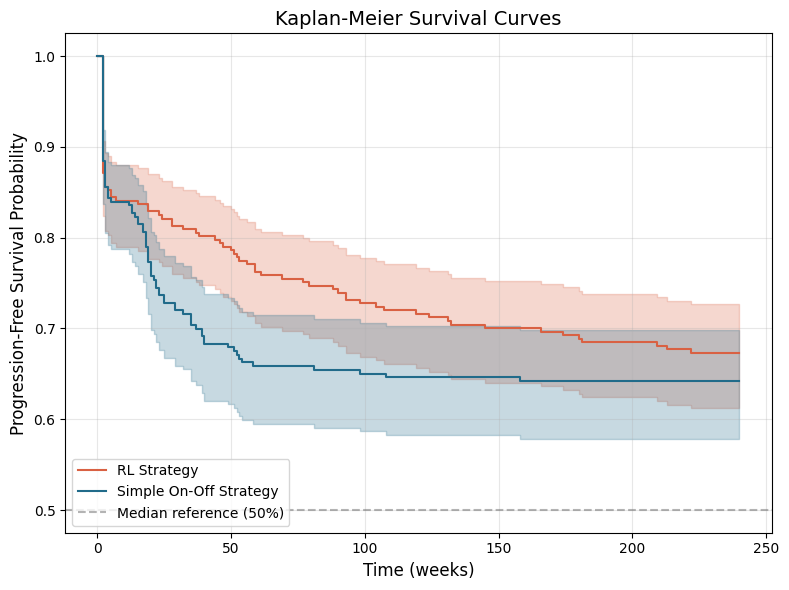

In [23]:
res_stats = survival_anal(df_RL, df_ONF)

# df.to_csv('simulation_results.csv', index=False)